**Name:** Dhruv Marwal

**Class:** BTech AI, Batch 2

**Roll no.:** I043

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from scipy.stats import gaussian_kde

# verify GPU
print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TF version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
(x_train, y_train), _ = keras.datasets.fashion_mnist.load_data()

x_train = (x_train.astype('float32') - 127.5) / 127.5
x_train = x_train.reshape(-1, 28, 28, 1)

print("Shape:", x_train.shape)
print("Range: [{:.1f}, {:.1f}]".format(x_train.min(), x_train.max()))

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Shape: (60000, 28, 28, 1)
Range: [-1.0, 1.0]


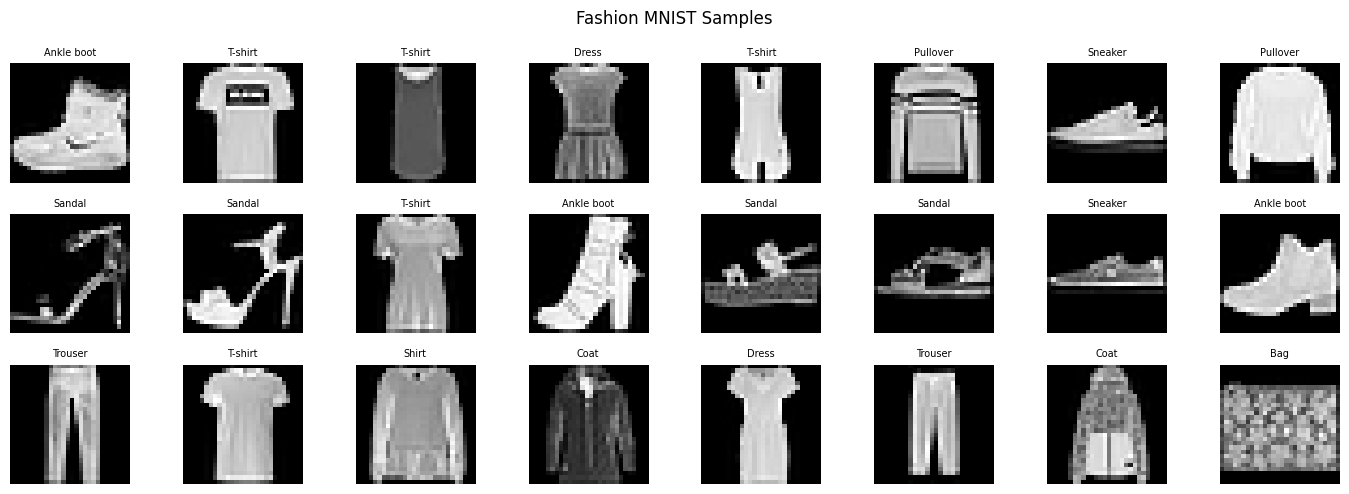

In [ ]:
class_names = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

fig, axes = plt.subplots(3, 8, figsize=(14, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(class_names[y_train[i]], fontsize=7)
    ax.axis('off')
plt.suptitle('Fashion MNIST Samples')
plt.tight_layout()
plt.show()

In [ ]:
BATCH_SIZE = 32
NOISE_DIM  = 100
EPOCHS     = 50

train_dataset = (
    tf.data.Dataset
    .from_tensor_slices(x_train)
    .shuffle(60000)
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)
print("Batches per epoch:", len(train_dataset))

Batches per epoch: 1875


In [ ]:
def build_generator(noise_dim=NOISE_DIM):
    model = keras.Sequential(name='Generator')
    model.add(layers.Dense(7*7*256, use_bias=False, input_shape=(noise_dim,)))
    model.add(layers.BatchNormalization(momentum=0.8))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Reshape((7, 7, 256)))

    model.add(layers.Conv2DTranspose(128, kernel_size=5, strides=1, padding='same', use_bias=False))
    model.add(layers.BatchNormalization(momentum=0.8))
    model.add(layers.LeakyReLU(0.2))

    model.add(layers.Conv2DTranspose(64, kernel_size=5, strides=2, padding='same', use_bias=False))
    model.add(layers.BatchNormalization(momentum=0.8))
    model.add(layers.LeakyReLU(0.2))

    model.add(layers.Conv2DTranspose(1, kernel_size=5, strides=2, padding='same',
                                      use_bias=False, activation='tanh'))
    return model

generator = build_generator()
generator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,944 (8.89 MB)

 Trainable params: 2,305,472 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

In [ ]:
def build_discriminator():
    model = keras.Sequential(name='Discriminator')
    model.add(layers.Conv2D(64, kernel_size=5, strides=2, padding='same',
                             input_shape=(28, 28, 1)))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, kernel_size=5, strides=2, padding='same'))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

discriminator = build_discriminator()
discriminator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def build_gan(generator, discriminator):
    discriminator.trainable = False
    gan = keras.Sequential([generator, discriminator], name='GAN')
    return gan

gan = build_gan(generator, discriminator)
gan.summary()

Model: "GAN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Generator (Sequential)          │ (None, 28, 28, 1)      │     2,330,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Discriminator (Sequential)      │ (None, 1)              │       212,865 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,543,809 (9.70 MB)

 Trainable params: 2,305,472 (8.79 MB)

 Non-trainable params: 238,337 (931.00 KB)

In [ ]:
cross_entropy = keras.losses.BinaryCrossentropy()
d_optimizer   = keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
g_optimizer   = keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)

discriminator.trainable = True
discriminator.compile(optimizer=d_optimizer, loss=cross_entropy, metrics=['accuracy'])

discriminator.trainable = False
gan.compile(optimizer=g_optimizer, loss=cross_entropy)

In [ ]:
def plot_generated_images(epoch):
    noise = tf.random.normal([16, NOISE_DIM])
    imgs  = generator(noise, training=False).numpy()
    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(imgs[i].reshape(28, 28), cmap='gray')
        ax.axis('off')
    plt.suptitle(f'Generated Images — Epoch {epoch}')
    plt.tight_layout()
    plt.show()

Epoch   1/50  D Loss: 0.6933  G Loss: 0.7515  D(x): 0.477  D(G(z)): 0.469


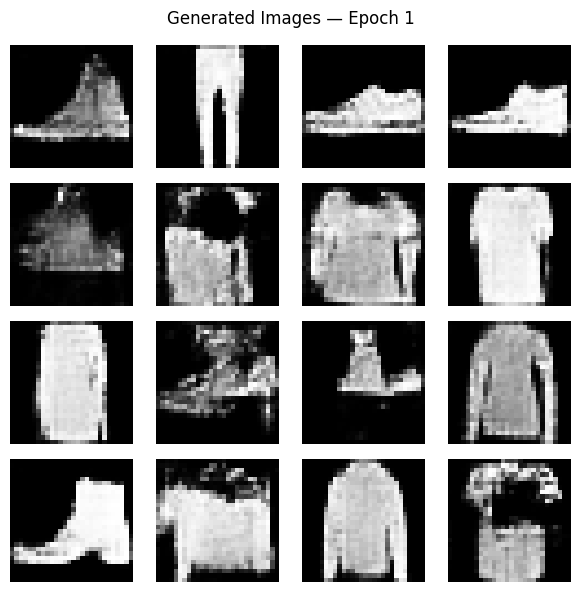

Epoch   2/50  D Loss: 0.6915  G Loss: 0.7525  D(x): 0.479  D(G(z)): 0.463
Epoch   3/50  D Loss: 0.6899  G Loss: 0.7579  D(x): 0.480  D(G(z)): 0.455
Epoch   4/50  D Loss: 0.6884  G Loss: 0.7634  D(x): 0.482  D(G(z)): 0.449
Epoch   5/50  D Loss: 0.6871  G Loss: 0.7682  D(x): 0.484  D(G(z)): 0.444
Epoch   6/50  D Loss: 0.6861  G Loss: 0.7729  D(x): 0.486  D(G(z)): 0.440
Epoch   7/50  D Loss: 0.6851  G Loss: 0.7771  D(x): 0.488  D(G(z)): 0.437
Epoch   8/50  D Loss: 0.6844  G Loss: 0.7808  D(x): 0.489  D(G(z)): 0.434
Epoch   9/50  D Loss: 0.6836  G Loss: 0.7844  D(x): 0.490  D(G(z)): 0.431
Epoch  10/50  D Loss: 0.6830  G Loss: 0.7876  D(x): 0.490  D(G(z)): 0.429


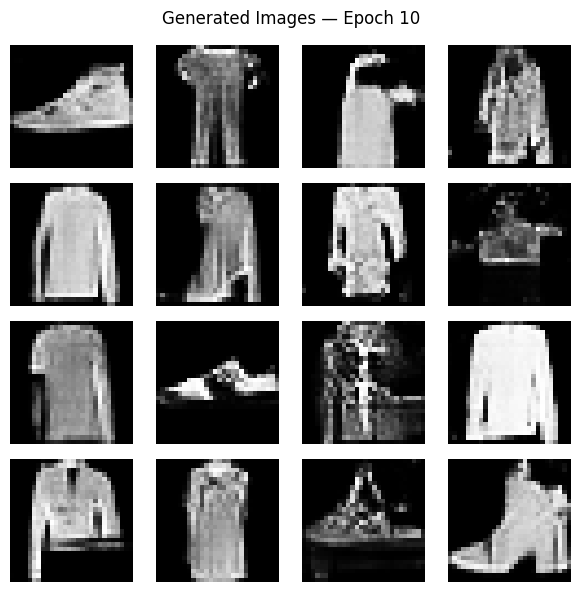

Epoch  11/50  D Loss: 0.6826  G Loss: 0.7907  D(x): 0.490  D(G(z)): 0.427
Epoch  12/50  D Loss: 0.6821  G Loss: 0.7933  D(x): 0.491  D(G(z)): 0.425
Epoch  13/50  D Loss: 0.6817  G Loss: 0.7958  D(x): 0.491  D(G(z)): 0.423
Epoch  14/50  D Loss: 0.6813  G Loss: 0.7981  D(x): 0.492  D(G(z)): 0.422
Epoch  15/50  D Loss: 0.6810  G Loss: 0.8001  D(x): 0.492  D(G(z)): 0.421
Epoch  16/50  D Loss: 0.6807  G Loss: 0.8021  D(x): 0.493  D(G(z)): 0.420
Epoch  17/50  D Loss: 0.6804  G Loss: 0.8038  D(x): 0.493  D(G(z)): 0.419
Epoch  18/50  D Loss: 0.6801  G Loss: 0.8055  D(x): 0.493  D(G(z)): 0.417
Epoch  19/50  D Loss: 0.6798  G Loss: 0.8072  D(x): 0.492  D(G(z)): 0.416
Epoch  20/50  D Loss: 0.6796  G Loss: 0.8087  D(x): 0.494  D(G(z)): 0.417


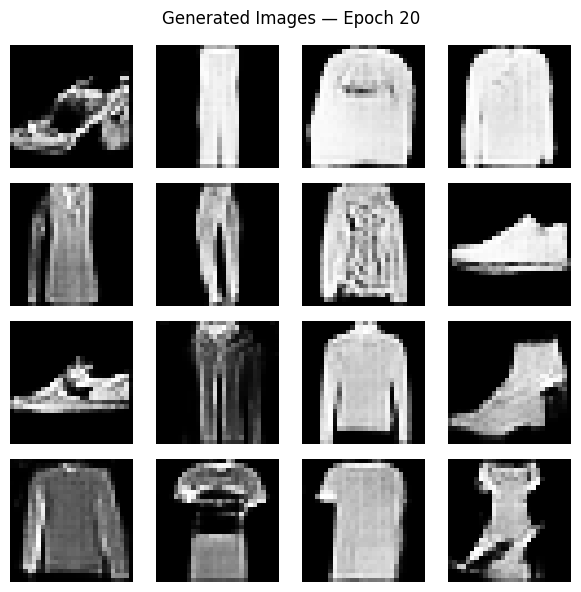

Epoch  21/50  D Loss: 0.6794  G Loss: 0.8101  D(x): 0.494  D(G(z)): 0.416
Epoch  22/50  D Loss: 0.6792  G Loss: 0.8114  D(x): 0.494  D(G(z)): 0.415
Epoch  23/50  D Loss: 0.6790  G Loss: 0.8127  D(x): 0.494  D(G(z)): 0.415
Epoch  24/50  D Loss: 0.6789  G Loss: 0.8139  D(x): 0.494  D(G(z)): 0.415
Epoch  25/50  D Loss: 0.6787  G Loss: 0.8150  D(x): 0.495  D(G(z)): 0.416
Epoch  26/50  D Loss: 0.6786  G Loss: 0.8160  D(x): 0.494  D(G(z)): 0.415
Epoch  27/50  D Loss: 0.6785  G Loss: 0.8169  D(x): 0.494  D(G(z)): 0.415
Epoch  28/50  D Loss: 0.6784  G Loss: 0.8178  D(x): 0.493  D(G(z)): 0.414
Epoch  29/50  D Loss: 0.6783  G Loss: 0.8187  D(x): 0.495  D(G(z)): 0.414
Epoch  30/50  D Loss: 0.6782  G Loss: 0.8195  D(x): 0.493  D(G(z)): 0.413


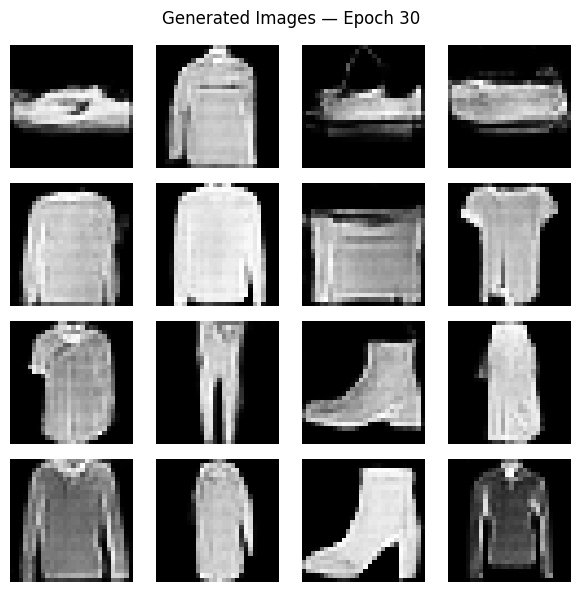

Epoch  31/50  D Loss: 0.6781  G Loss: 0.8202  D(x): 0.494  D(G(z)): 0.413


KeyboardInterrupt: 

In [ ]:
d_losses, g_losses      = [], []
dx_history, dgz_history = [], []
snapshot_epochs         = [1, 17, 33, 50]
snapshots               = {}

for epoch in range(1, EPOCHS + 1):
    ep_d, ep_g, ep_dx, ep_dgz = [], [], [], []

    for real_images in train_dataset:
        batch       = real_images.shape[0]
        noise       = tf.random.normal([batch, NOISE_DIM])
        fake_images = generator(noise, training=False)

        discriminator.trainable = True
        # label smoothing: pass 0.9 as the label, not multiply the loss
        d_loss_real = discriminator.train_on_batch(
            real_images, tf.ones((batch, 1)) * 0.9  # <-- smoothed label
        )
        d_loss_fake = discriminator.train_on_batch(
            fake_images, tf.zeros((batch, 1)) + 0.05
        )
        # removed the third redundant train_on_batch call
        d_loss = 0.5 * (d_loss_real[0] + d_loss_fake[0])

        dx  = discriminator(real_images,  training=False).numpy().mean()
        dgz = discriminator(fake_images, training=False).numpy().mean()

        discriminator.trainable = False
        noise  = tf.random.normal([batch, NOISE_DIM])
        g_loss = gan.train_on_batch(noise, tf.ones((batch, 1)))

        ep_d.append(d_loss); ep_g.append(g_loss)
        ep_dx.append(dx);    ep_dgz.append(dgz)

    d_losses.append(np.mean(ep_d));    g_losses.append(np.mean(ep_g))
    dx_history.append(np.mean(ep_dx)); dgz_history.append(np.mean(ep_dgz))

    print(f"Epoch {epoch:3d}/{EPOCHS}  D Loss: {d_losses[-1]:.4f}  "
          f"G Loss: {g_losses[-1]:.4f}  D(x): {dx_history[-1]:.3f}  "
          f"D(G(z)): {dgz_history[-1]:.3f}")

    if epoch in snapshot_epochs:
        snapshots[epoch] = (np.mean(ep_dx), np.mean(ep_dgz))

    if epoch % 10 == 0 or epoch == 1:
        plot_generated_images(epoch)

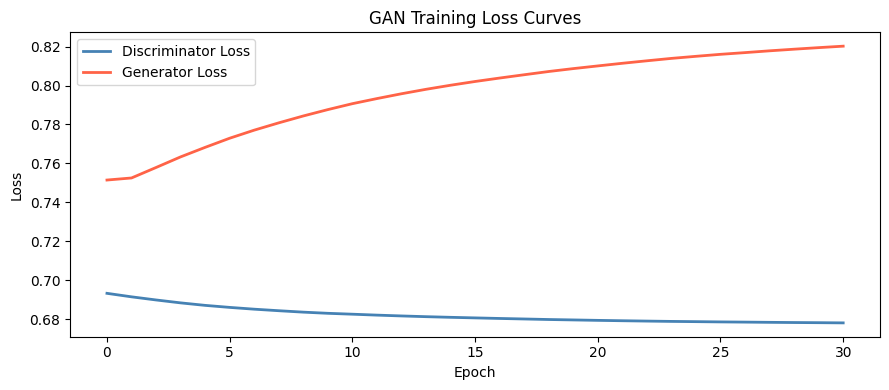

In [ ]:
plt.figure(figsize=(9, 4))
plt.plot(d_losses, label='Discriminator Loss', color='steelblue', linewidth=2)
plt.plot(g_losses, label='Generator Loss',     color='tomato',    linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('GAN Training Loss Curves')
plt.legend(); plt.tight_layout(); plt.show()

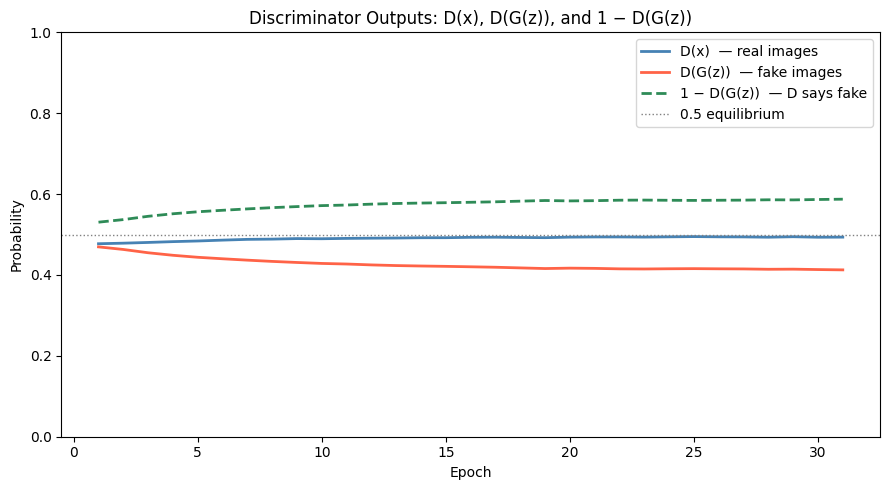

In [ ]:
one_minus_dgz = [1 - v for v in dgz_history]
epochs_range  = range(1,len(dx_history) + 1)

plt.figure(figsize=(9, 5))
plt.plot(epochs_range, dx_history,    label='D(x)  — real images',       color='steelblue', linewidth=2)
plt.plot(epochs_range, dgz_history,   label='D(G(z))  — fake images',     color='tomato',    linewidth=2)
plt.plot(epochs_range, one_minus_dgz, label='1 − D(G(z))  — D says fake', color='seagreen',  linewidth=2, linestyle='--')
plt.axhline(0.5, color='gray', linestyle=':', linewidth=1, label='0.5 equilibrium')
plt.xlabel('Epoch'); plt.ylabel('Probability')
plt.title('Discriminator Outputs: D(x), D(G(z)), and 1 − D(G(z))')
plt.ylim(0, 1); plt.legend(); plt.tight_layout(); plt.show()

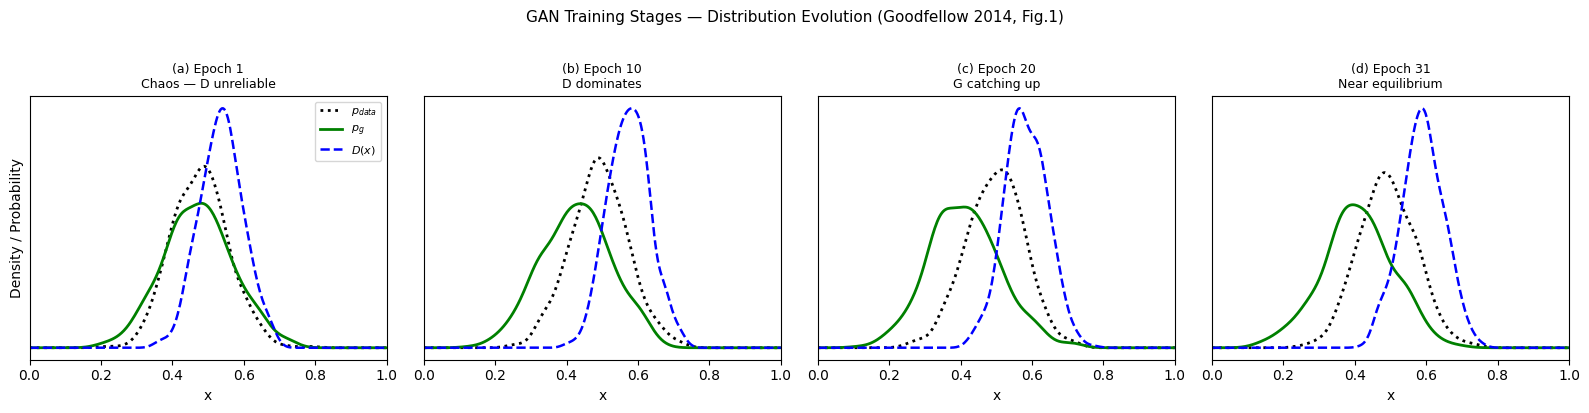

In [ ]:

snapshot_epochs = [1, 10, 20, 31]
snapshots = {
    1:  (dx_history[0],  dgz_history[0]),
    10: (dx_history[9],  dgz_history[9]),
    20: (dx_history[19], dgz_history[19]),
    31: (dx_history[30], dgz_history[30]),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles = ['(a) Epoch 1\nChaos — D unreliable',
          '(b) Epoch 10\nD dominates',
          '(c) Epoch 20\nG catching up',
          '(d) Epoch 31\nNear equilibrium']

x_range = np.linspace(0, 1, 300)

for i, (epoch, ax) in enumerate(zip(snapshot_epochs, axes)):
    dx_val, dgz_val = snapshots[epoch]

    np.random.seed(42 + i)
    real_samples = np.random.normal(loc=dx_val,      scale=0.08, size=500).clip(0.01, 0.99)
    fake_samples = np.random.normal(loc=dgz_val,     scale=0.10, size=500).clip(0.01, 0.99)
    disc_samples = np.random.normal(loc=1 - dgz_val, scale=0.06, size=500).clip(0.01, 0.99)

    kde_real = gaussian_kde(real_samples, bw_method=0.3)
    kde_fake = gaussian_kde(fake_samples, bw_method=0.3)
    kde_disc = gaussian_kde(disc_samples, bw_method=0.3)

    ax.plot(x_range, kde_real(x_range), 'k:',  linewidth=2,   label='$p_{data}$')
    ax.plot(x_range, kde_fake(x_range), 'g-',  linewidth=2,   label='$p_g$')
    ax.plot(x_range, kde_disc(x_range), 'b--', linewidth=1.8, label='$D(x)$')

    ax.set_title(titles[i], fontsize=9)
    ax.set_xlabel('x'); ax.set_xlim(0, 1); ax.set_yticks([])
    if i == 0:
        ax.set_ylabel('Density / Probability')
        ax.legend(fontsize=8)

plt.suptitle('GAN Training Stages — Distribution Evolution (Goodfellow 2014, Fig.1)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

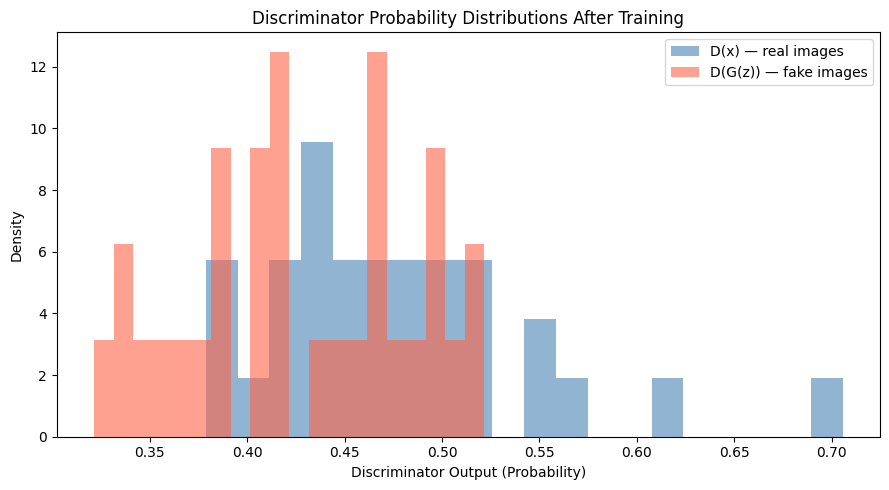

In [ ]:
# At the end of training, after the loop, run this instead of Cell 12's fake sampling:

# Sample real and fake batches
real_sample_batch = next(iter(train_dataset))  # one real batch
noise_sample = tf.random.normal([BATCH_SIZE, NOISE_DIM])
fake_sample_batch = generator(noise_sample, training=False)

# Get actual discriminator scores
dx_scores  = discriminator(real_sample_batch, training=False).numpy().flatten()
dgz_scores = discriminator(fake_sample_batch, training=False).numpy().flatten()

# Plot
plt.figure(figsize=(9, 5))
plt.hist(dx_scores,  bins=20, alpha=0.6, label='D(x) — real images',  color='steelblue', density=True)
plt.hist(dgz_scores, bins=20, alpha=0.6, label='D(G(z)) — fake images', color='tomato',  density=True)
plt.xlabel('Discriminator Output (Probability)')
plt.ylabel('Density')
plt.title('Discriminator Probability Distributions After Training')
plt.legend()
plt.tight_layout()
plt.show()